# Immunogenicity Benchmarking on the TESLA Dataset

**Purpose:** Evaluate whether MHCflurry, HLApollo, and combined scoring can identify immunogenic neoantigens from the TESLA consortium benchmark with experimentally validated labels.

**Reference:** Wells et al., *Nature Biotechnology* 2020. The TESLA consortium applied multiple neoantigen prediction pipelines to shared patient data and compared results to experimental immunogenicity readouts.

**Data requirements:**
- `data/TESLA_supp/s4_pMHC_batch_1.xlsx` — 608 peptides, 37 immunogenic (batch 1)
- `data/TESLA_supp/s7_pMHC_validation_cohort.xlsx` — 310 peptides, 4 immunogenic (batch 2)
- HLApollo binary: `tools/HLApollo/HLA-Apollo` (optional)

**Metric definitions:**
- **FR** (fraction ranked): fraction of immunogenic peptides that appear in the top 100
- **TTIF** (top-twenty immunogenic fraction): fraction of immunogenic peptides in the top 20
- **AUPRC**: area under the precision-recall curve

## 1. Load TESLA data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, precision_recall_curve
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

from neoantigen_pipeline.prediction.mhcflurry import MHCflurryPredictor
from neoantigen_pipeline.config import MHCIPredictionConfig
from neoantigen_pipeline.prediction.hlapollo import HLApolloPredictor

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline

TESLA_DIR = Path("../data/TESLA_supp")
# HLAPOLLO_BINARY kept for reference; Docker is used by default
HLAPOLLO_BINARY = Path("../tools/HLApollo/HLA-Apollo")

# Cancer tissue type mapping
CANCER_TISSUE_MAP: dict[str, str] = {
    "melanoma": "skin",
    "NSCLC": "lung",
    "breast_cancer": "breast",
    "LUAD": "lung",
    "SKCM": "skin",
}

In [2]:
def load_tesla_batch(path: Path) -> pd.DataFrame:
    """Load a TESLA supplementary Excel file and parse peptide/allele columns.

    PMHC format is "A*02:01_SIINFEKLV" (allele_peptide, split on first underscore).
    Immunogenicity is stored in the VALIDATED column (bool or 0/1).
    """
    df = pd.read_excel(path)

    # Normalise column names
    df.columns = [c.strip().upper().replace(" ", "_") for c in df.columns]

    # Parse PMHC → allele + peptide (split on first underscore only)
    if "PMHC" in df.columns:
        parsed = df["PMHC"].str.split("_", n=1, expand=True)
        df["allele"] = "HLA-" + parsed[0].str.strip()
        df["peptide"] = parsed[1].str.strip()
    elif "MHC" in df.columns and "ALT_EPI_SEQ" in df.columns:
        df["allele"] = "HLA-" + df["MHC"].str.strip()
        df["peptide"] = df["ALT_EPI_SEQ"].str.strip()

    # Immunogenicity: VALIDATED column (True/False or 1/0)
    if "VALIDATED" in df.columns:
        df["immunogenic"] = df["VALIDATED"].astype(int)
    else:
        immuno_col = next((c for c in df.columns if "IMMUNO" in c), None)
        if immuno_col:
            df["immunogenic"] = df[immuno_col].astype(int)

    return df


batch1_path = TESLA_DIR / "s4_pMHC_batch_1.xlsx"
batch2_path = TESLA_DIR / "s7_pMHC_validation_cohort.xlsx"

if batch1_path.exists():
    batch1 = load_tesla_batch(batch1_path)
    print(f"Batch 1: {len(batch1)} peptides, {batch1['immunogenic'].sum()} immunogenic")
    # display(batch1[["PMHC", "allele", "peptide", "immunogenic"]].head())
    print(batch1[["PMHC", "allele", "peptide", "immunogenic"]].head())
else:
    print(f"Batch 1 file not found: {batch1_path}")
    print("Download from the TESLA paper supplementary data.")
    batch1 = None

if batch2_path.exists():
    batch2 = load_tesla_batch(batch2_path)
    print(f"Batch 2: {len(batch2)} peptides, {batch2['immunogenic'].sum()} immunogenic")
else:
    batch2 = None

Batch 1: 608 peptides, 37 immunogenic
                  PMHC       allele      peptide  immunogenic
0    A*01:01_ASSFLKSFY  HLA-A*01:01    ASSFLKSFY            0
1   A*01:01_ATLFSDSWYY  HLA-A*01:01   ATLFSDSWYY            0
2  A*01:01_CSDSGKSFINY  HLA-A*01:01  CSDSGKSFINY            0
3    A*01:01_CVDWLIAVY  HLA-A*01:01    CVDWLIAVY            0
4    A*01:01_DTDSRFISY  HLA-A*01:01    DTDSRFISY            0
Batch 2: 310 peptides, 4 immunogenic


In [3]:
print(batch1.groupby("PATIENT_ID")["TISSUE_TYPE"].first())

PATIENT_ID
1     PBMC
2     PBMC
3     PBMC
10     TIL
12     TIL
16     TIL
Name: TISSUE_TYPE, dtype: str


## 2. Run predictors on TESLA peptides

In [4]:
def run_predictors_per_allele(df: pd.DataFrame, cache, mhcflurry, apollo) -> pd.DataFrame:
    """Run MHCflurry and HLApollo grouped by allele, storing results in-place.

    Groups peptides by their specific allele so each predictor call uses a
    single-allele genotype. This avoids passing all 13 TESLA alleles pooled
    together, which is not a valid genotype for MHCflurry.
    """
    peptides = df["peptide"].tolist()
    unique_alleles = df["allele"].unique().tolist()

    # ── MHCflurry (group by allele) ──────────────────────────────────────────
    mf_key = cache.make_key("mhcflurry_tesla", len(peptides), sorted(unique_alleles))
    mf_cached = cache.get(mf_key)
    if mf_cached is None:
        print("Running MHCflurry on TESLA batch 1 (grouped by allele)...")
        mf_results: dict[int, object] = {}
        for allele, group in df.groupby("allele"):
            preds = mhcflurry.predict(group["peptide"].tolist(), [allele])
            for idx, pred in zip(group.index, preds):
                mf_results[idx] = pred
        df["mf_presentation_score"] = [mf_results[i].presentation_score for i in df.index]
        df["mf_percentile"] = [mf_results[i].presentation_percentile for i in df.index]
        cache.put(mf_key, df[["mf_presentation_score", "mf_percentile"]])
        print(f"Done. Ran {len(unique_alleles)} MHCflurry calls.")
    else:
        print(f"Loaded {len(mf_cached)} cached MHCflurry results")
        df["mf_presentation_score"] = mf_cached["mf_presentation_score"].values
        df["mf_percentile"] = mf_cached["mf_percentile"].values

    # ── HLApollo (group by allele) ───────────────────────────────────────────
    ap_key = cache.make_key("hlapollo_tesla", len(peptides), sorted(unique_alleles))
    ap_cached = cache.get(ap_key)
    if ap_cached is None:
        print("Running HLApollo on TESLA batch 1 (grouped by allele)...")
        ap_results: dict[int, object] = {}
        for allele, group in df.groupby("allele"):
            preds = apollo.predict(group["peptide"].tolist(), [allele])
            for idx, pred in zip(group.index, preds):
                ap_results[idx] = pred
        df["ap_score"] = [ap_results[i].presentation_score for i in df.index]
        df["ap_percentile"] = [ap_results[i].presentation_percentile for i in df.index]
        cache.put(ap_key, df[["ap_score", "ap_percentile"]])
        print(f"Done. Ran {len(unique_alleles)} HLApollo calls.")
    else:
        print(f"Loaded {len(ap_cached)} cached HLApollo results")
        df["ap_score"] = ap_cached["ap_score"].values
        df["ap_percentile"] = ap_cached["ap_percentile"].values

    return df


if batch1 is not None:
    from neoantigen_pipeline.results.cache import PredictionCache
    cache = PredictionCache("../results/cache")

    mf_config = MHCIPredictionConfig(alleles=())
    mhcflurry = MHCflurryPredictor(mf_config)
    apollo = HLApolloPredictor()

    batch1 = run_predictors_per_allele(batch1, cache, mhcflurry, apollo)

Loaded 608 cached MHCflurry results
Loaded 608 cached HLApollo results


In [5]:
print(batch1.head())

                  PMHC  PATIENT_ID TISSUE_TYPE      MHC  ALT_EPI_SEQ  PEP_LEN  \
0    A*01:01_ASSFLKSFY           3        PBMC  A*01:01    ASSFLKSFY        9   
1   A*01:01_ATLFSDSWYY           3        PBMC  A*01:01   ATLFSDSWYY       10   
2  A*01:01_CSDSGKSFINY           3        PBMC  A*01:01  CSDSGKSFINY       11   
3    A*01:01_CVDWLIAVY           2        PBMC  A*01:01    CVDWLIAVY        9   
4    A*01:01_DTDSRFISY           3        PBMC  A*01:01    DTDSRFISY        9   

   MEASURED_BINDING_AFFINITY  NETMHC_PAN_BINDING_AFFINITY  TUMOR_ABUNDANCE  \
0                       45.0                        132.1        57.819051   
1                       33.0                        251.7        51.857250   
2                       77.0                         64.8        30.389590   
3                        0.0                         38.7       159.967690   
4                        3.0                         24.0        45.765280   

   BINDING_STABILITY  ...  TCR_NANOPARTICLE 

## 3. Individual predictor evaluation


Batch 1 evaluation metrics:


,auprc,fr,ttif
HLApollo (logit),0.189,0.568,0.135
HLApollo (percentile),0.189,0.568,0.135
MHCflurry (presentation),0.178,0.486,0.108
MHCflurry (percentile),0.176,0.514,0.108
BINDING_STABILITY,0.156,0.324,0.135
NETMHC_PAN_BINDING_AFFINITY,0.138,0.351,0.108
TUMOR_ABUNDANCE,0.105,0.405,0.000
AGRETOPICITY,0.080,0.216,0.027
FOREIGNNESS,0.071,0.189,0.027


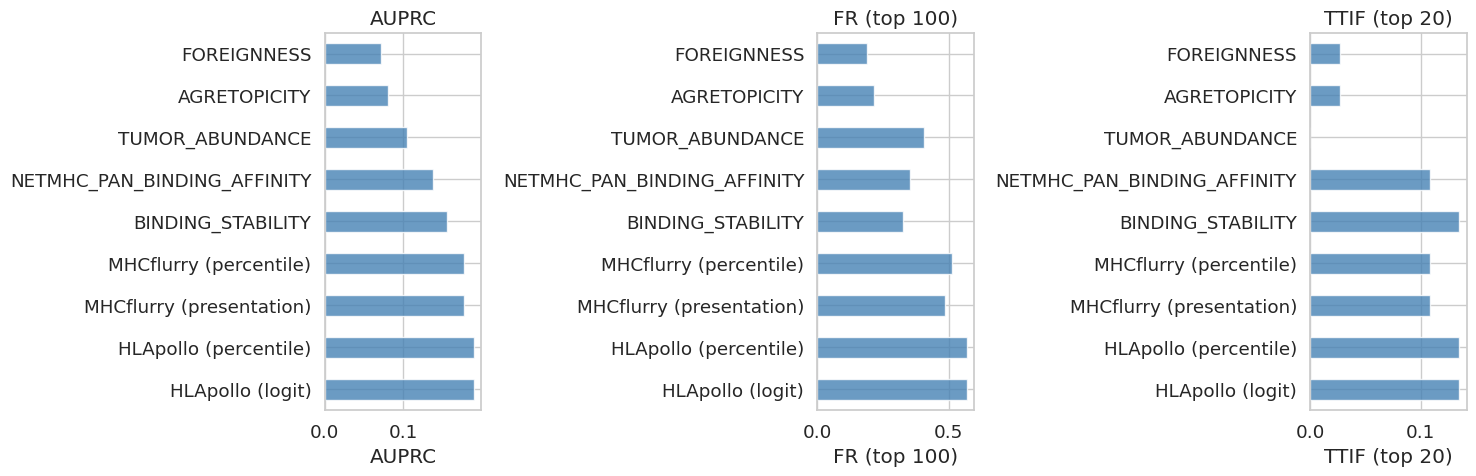

In [6]:
def compute_metrics(scores: pd.Series, labels: pd.Series, higher_is_better: bool = True) -> dict:
    """Compute ranking metrics for a predictor.

    Args:
        scores: Predictor scores (higher = better if higher_is_better else lower = better).
        labels: Binary immunogenicity labels (1 = immunogenic).
        higher_is_better: If False, negate scores before ranking.

    Returns:
        Dict with AUPRC, FR (top 100), TTIF (top 20).

    Notes:
        NaN handling: AUPRC is computed on rows with valid scores only.
        For ranking metrics (FR, TTIF), NaN scores are filled with a value
        worse than the observed minimum so they rank last.
    """
    # Reset to positional index so boolean masks align regardless of caller index
    scores = scores.reset_index(drop=True)
    labels = labels.reset_index(drop=True)

    if scores.isna().all():
        return {"auprc": np.nan, "fr": np.nan, "ttif": np.nan}

    # AUPRC: exclude NaN rows entirely
    valid = scores.notna()
    s_valid = scores[valid]
    lab_valid = labels[valid]
    if not higher_is_better:
        s_valid = -s_valid
    prec, rec, _ = precision_recall_curve(lab_valid, s_valid)
    auprc_val = auc(rec, prec)

    # Ranking metrics: fill NaN with a value worse than the minimum observed
    s_full = scores.copy()
    if higher_is_better:
        s_full = s_full.fillna(s_full.min() - 1)
    else:
        s_full = s_full.fillna(s_full.max() + 1)
        s_full = -s_full

    sorted_idx = s_full.argsort()[::-1]
    sorted_labels = labels.values[sorted_idx]
    n_immuno = labels.sum()

    fr = sorted_labels[:100].sum() / n_immuno if n_immuno > 0 else 0.0
    ttif = sorted_labels[:20].sum() / n_immuno if n_immuno > 0 else 0.0

    return {"auprc": auprc_val, "fr": fr, "ttif": ttif}


if batch1 is not None:
    predictors = {
        "MHCflurry (presentation)": (batch1["mf_presentation_score"], True),
        "MHCflurry (percentile)": (batch1["mf_percentile"], False),
    }

    if not batch1["ap_score"].isna().all():
        predictors["HLApollo (logit)"] = (batch1["ap_score"], True)
        predictors["HLApollo (percentile)"] = (batch1["ap_percentile"], False)

    # Add TESLA precomputed features if available
    for col, higher in [
        ("NETMHC_PAN_BINDING_AFFINITY", False),
        ("BINDING_STABILITY", True),
        ("AGRETOPICITY", True),
        ("FOREIGNNESS", True),
        ("TUMOR_ABUNDANCE", True),
    ]:
        if col in batch1.columns:
            predictors[col] = (batch1[col], higher)

    metrics = {
        name: compute_metrics(scores, batch1["immunogenic"], higher)
        for name, (scores, higher) in predictors.items()
    }

    metrics_df = pd.DataFrame(metrics).T.sort_values("auprc", ascending=False)
    print("\nBatch 1 evaluation metrics:")
    display(metrics_df.round(3))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, col, label in zip(axes, ["auprc", "fr", "ttif"], ["AUPRC", "FR (top 100)", "TTIF (top 20)"]):
        metrics_df[col].plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
        ax.set_xlabel(label)
        ax.set_title(label)
    plt.tight_layout()
    plt.show()

## 4. Combined scoring

In [7]:
if batch1 is not None:
    feature_cols = ["mf_presentation_score"]
    if not batch1["ap_score"].isna().all():
        feature_cols.append("ap_score")
    for col in ["AGRETOPICITY", "TUMOR_ABUNDANCE", "BINDING_STABILITY"]:
        if col in batch1.columns:
            feature_cols.append(col)

    train_data = batch1[feature_cols + ["immunogenic"]].dropna()

    if "PATIENT_ID" in batch1.columns:
        groups = train_data.index.map(batch1["PATIENT_ID"])
        logo = LeaveOneGroupOut()
        cv = logo.split(train_data[feature_cols], train_data["immunogenic"], groups)
    else:
        from sklearn.model_selection import StratifiedKFold
        cv = StratifiedKFold(n_splits=5).split(train_data[feature_cols], train_data["immunogenic"])

    scaler = StandardScaler()
    lr = LogisticRegression(max_iter=500, class_weight="balanced")

    oof_probs = np.zeros(len(train_data))
    for train_idx, val_idx in cv:
        X_tr = scaler.fit_transform(train_data[feature_cols].values[train_idx])
        X_val = scaler.transform(train_data[feature_cols].values[val_idx])
        y_tr = train_data["immunogenic"].values[train_idx]
        lr.fit(X_tr, y_tr)
        oof_probs[val_idx] = lr.predict_proba(X_val)[:, 1]

    combined_metrics = compute_metrics(
        pd.Series(oof_probs), train_data["immunogenic"], higher_is_better=True
    )
    print("Combined model (CV) metrics:")
    print(f"  AUPRC: {combined_metrics['auprc']:.3f}")
    print(f"  FR:    {combined_metrics['fr']:.3f}")
    print(f"  TTIF:  {combined_metrics['ttif']:.3f}")

Combined model (CV) metrics:
  AUPRC: 0.169
  FR:    0.655
  TTIF:  0.103


## 5. Validation on batch 2

In [8]:
if batch2 is not None and batch1 is not None:
    # Train on all of batch1, evaluate on batch2
    X_train = scaler.fit_transform(train_data[feature_cols].values)
    y_train = train_data["immunogenic"].values
    lr.fit(X_train, y_train)

    # Run predictors on batch2 using the same per-allele grouping
    ap_key2 = cache.make_key("hlapollo_tesla_b2", len(batch2), sorted(batch2["allele"].unique().tolist()))
    mf_key2 = cache.make_key("mhcflurry_tesla_b2", len(batch2), sorted(batch2["allele"].unique().tolist()))

    mf_cached2 = cache.get(mf_key2)
    if mf_cached2 is None:
        mf_results2: dict[int, object] = {}
        for allele, group in batch2.groupby("allele"):
            preds = mhcflurry.predict(group["peptide"].tolist(), [allele])
            for idx, pred in zip(group.index, preds):
                mf_results2[idx] = pred
        batch2["mf_presentation_score"] = [mf_results2[i].presentation_score for i in batch2.index]
        cache.put(mf_key2, batch2[["mf_presentation_score"]])
    else:
        batch2["mf_presentation_score"] = mf_cached2["mf_presentation_score"].values

    ap_cached2 = cache.get(ap_key2)
    if ap_cached2 is None:
        ap_results2: dict[int, object] = {}
        for allele, group in batch2.groupby("allele"):
            preds = apollo.predict(group["peptide"].tolist(), [allele])
            for idx, pred in zip(group.index, preds):
                ap_results2[idx] = pred
        batch2["ap_score"] = [ap_results2[i].presentation_score for i in batch2.index]
        cache.put(ap_key2, batch2[["ap_score"]])
    else:
        batch2["ap_score"] = ap_cached2["ap_score"].values

    for col in ["AGRETOPICITY", "TUMOR_ABUNDANCE", "BINDING_STABILITY"]:
        if col not in batch2.columns:
            batch2[col] = np.nan

    test_data = batch2[feature_cols].fillna(0.0)
    X_test = scaler.transform(test_data.values)
    test_probs = lr.predict_proba(X_test)[:, 1]

    batch2_metrics = compute_metrics(
        pd.Series(test_probs), batch2["immunogenic"], higher_is_better=True
    )
    print("Batch 2 (held-out) evaluation:")
    print(f"  AUPRC: {batch2_metrics['auprc']:.3f}")
    print(f"  FR:    {batch2_metrics['fr']:.3f}")
    print(f"  TTIF:  {batch2_metrics['ttif']:.3f}")
    print("  Note: batch 2 has only 4 positives — results have high variance.")
else:
    print("Batch 2 data not available.")

Batch 2 (held-out) evaluation:
  AUPRC: 0.225
  FR:    1.000
  TTIF:  1.000
  Note: batch 2 has only 4 positives — results have high variance.


## 6. Feature importance

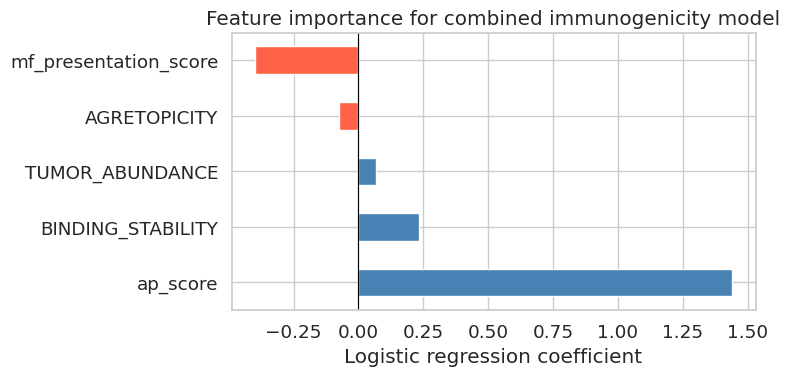

Feature coefficients:
ap_score                 1.438516
BINDING_STABILITY        0.233090
TUMOR_ABUNDANCE          0.068016
AGRETOPICITY            -0.072928
mf_presentation_score   -0.397045


In [9]:
if batch1 is not None and len(feature_cols) > 1:
    coef = lr.coef_[0]
    importance = pd.Series(coef, index=feature_cols).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    importance.plot(kind="barh", ax=ax, color=["steelblue" if c >= 0 else "tomato" for c in importance])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Logistic regression coefficient")
    ax.set_title("Feature importance for combined immunogenicity model")
    plt.tight_layout()
    plt.show()

    print("Feature coefficients:")
    print(importance.to_string())

## 7. Precision-recall curves

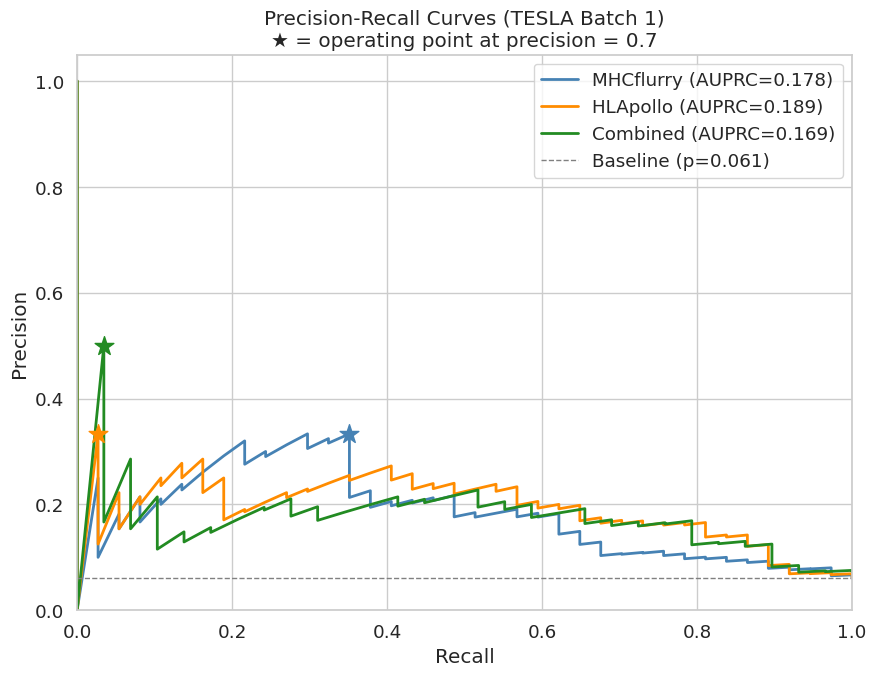

In [16]:
if batch1 is not None:
    fig, ax = plt.subplots(figsize=(9, 7))

    plot_predictors = {
        "MHCflurry": (batch1["mf_presentation_score"], True, "steelblue"),
    }
    if not batch1["ap_score"].isna().all():
        plot_predictors["HLApollo"] = (batch1["ap_score"], True, "darkorange")

    if "oof_probs" in dir():
        # Align OOF predictions back to batch1's full index (NaN for dropped rows)
        oof_series = pd.Series(oof_probs, index=train_data.index).reindex(batch1.index)
        plot_predictors["Combined"] = (oof_series, True, "forestgreen")

    n_immuno = batch1["immunogenic"].sum()
    baseline_prec = n_immuno / len(batch1)

    for name, (scores, higher, color) in plot_predictors.items():
        if scores.isna().all():
            continue
        valid = scores.notna()
        s = scores[valid] if higher else -scores[valid]
        lab = batch1["immunogenic"][valid]
        prec, rec, _ = precision_recall_curve(lab, s)
        area = auc(rec, prec)
        ax.plot(rec, prec, label=f"{name} (AUPRC={area:.3f})", color=color, linewidth=2)

        # Mark operating point at precision = 0.7
        idx = np.argmin(abs(prec[:-1] - 0.7))
        if 0 < idx < len(rec) - 1:
            ax.scatter(rec[idx], prec[idx], color=color, marker="*", s=200, zorder=5)

    ax.axhline(baseline_prec, color="gray", linestyle="--", linewidth=1, label=f"Baseline (p={baseline_prec:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curves (TESLA Batch 1)\n★ = operating point at precision = 0.7")
    ax.legend(loc="upper right")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.show()

## 9. Comparison to TESLA consortium

In [14]:
if batch1 is not None:
    n_total = len(batch1)
    n_immuno_total = batch1["immunogenic"].sum()

    print("=" * 60)
    print("TESLA Benchmark Context")
    print("=" * 60)
    print(f"Total peptides:     {n_total}")
    print(f"Immunogenic:        {n_immuno_total}")
    print()
    print("TESLA reference (Wells et al. 2020):")
    print("  No team placed >20 of 37 immunogenic peptides in their top 100.")
    print()
    print("Our pipeline results:")

    for name, (scores, higher, _) in plot_predictors.items():
        if scores.isna().all():
            continue
        s = scores if higher else -scores
        top100 = batch1["immunogenic"].values[s.argsort()[::-1][:100]]
        n_in_top100 = int(top100.sum())
        print(f"  {name}: {n_in_top100}/{n_immuno_total} immunogenic in top 100 "
              f"({100 * n_in_top100 / n_immuno_total:.0f}%)")

TESLA Benchmark Context
Total peptides:     608
Immunogenic:        37

TESLA reference (Wells et al. 2020):
  No team placed >20 of 37 immunogenic peptides in their top 100.

Our pipeline results:
  MHCflurry: 18/37 immunogenic in top 100 (49%)
  HLApollo: 21/37 immunogenic in top 100 (57%)
